In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [208]:
train = pd.read_csv("mlp-jan-2026-kaggle-assignment-2/train.csv")
test = pd.read_csv("mlp-jan-2026-kaggle-assignment-2/test.csv")
sample = pd.read_csv("mlp-jan-2026-kaggle-assignment-2/sample_submission.csv")


In [209]:
train["is_train"] = 1
test["is_train"] = 0
df = pd.concat((train, test))

In [210]:
df.shape, train.shape, test.shape

((8124, 27), (7000, 27), (1124, 26))

# Main code starts:

## EDA and Feature Engineering for Mushroom Dataset

In [211]:
numericals_cols = df.select_dtypes(include = ["int64", "float64"]).columns.to_list()
categorical_cols = [i for i in df.columns if i not in numericals_cols]

print(numericals_cols)

display("Categorical cols:" ,categorical_cols)

['ID', 'mushroom_id', 'number_of_bruises', 'ring-number', 'is_train']


'Categorical cols:'

['cap-shape',
 'cap-surface',
 'cap-color',
 'bruises',
 'odor',
 'gill-attachment',
 'gill-spacing',
 'gill-size',
 'gill-color',
 'stalk-shape',
 'stalk-root',
 'stalk-surface-above-ring',
 'stalk-surface-below-ring',
 'stalk-color-above-ring',
 'stalk-color-below-ring',
 'veil-type',
 'veil-color',
 'ring-type',
 'spore-print-color',
 'population',
 'habitat',
 'class']

In [212]:
df["number_of_bruises"].unique() # candidate for encoding
df["ring-number"].unique() # candidate for encoding
df["ring-number"] = df["ring-number"]

In [213]:
df.isna().sum()

ID                             0
mushroom_id                    0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
number_of_bruises              0
odor                        3528
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                   192
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                   36
ring-type                     36
spore-print-color              0
population                     0
habitat                        0
class                       1124
is_train                       0
dtype: int64

### handling missing values 

In [214]:
df.info()

<class 'pandas.DataFrame'>
Index: 8124 entries, 0 to 1123
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        8124 non-null   int64  
 1   mushroom_id               8124 non-null   int64  
 2   cap-shape                 8124 non-null   str    
 3   cap-surface               8124 non-null   str    
 4   cap-color                 8124 non-null   str    
 5   bruises                   8124 non-null   str    
 6   number_of_bruises         8124 non-null   int64  
 7   odor                      4596 non-null   str    
 8   gill-attachment           8124 non-null   str    
 9   gill-spacing              8124 non-null   str    
 10  gill-size                 8124 non-null   str    
 11  gill-color                8124 non-null   str    
 12  stalk-shape               8124 non-null   str    
 13  stalk-root                7932 non-null   str    
 14  stalk-surface-above-ring

In [215]:
numerical_impts = [i for i in numericals_cols if df[i].isna().sum() > 0 and i != "class"]
categorical_impts = [i for i in categorical_cols if df[i].isna().sum() > 0 and i != "class"]

from sklearn.impute import SimpleImputer

if numerical_impts: 
    imp = SimpleImputer(missing_values=np.nan, strategy='mean')
    df[numerical_impts] = imp.fit_transform(df[numerical_impts])

if categorical_impts:
    imp_cat = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
    df[categorical_impts] = imp_cat.fit_transform(df[categorical_impts])


In [217]:
# df.isna().sum()

In [218]:
df.duplicated().sum()

np.int64(0)

In [ ]:
for i in df.columns:
    print(i,": ",df[i].unique(), '\n')

In [219]:
train_viz = df[df["is_train"]==1]
test_viz = df[df["is_train"]==0]

In [220]:
# df["veil-type"].unique() #only 1 value thus of no use, it's noise
df.drop(["veil-type", "mushroom_id", "ID"], inplace= True, axis = 1) #dropping not useful cols

Imp learning: Converting categorical data to numerical data using label encoding and one-hot encoding, would not be helpful as this dataset has a lot of categorical featuers and if we used CatBoost or xgboost then we can directly use the categorical features without encoding them. So we will not do any encoding for the categorical features and will directly use them in the model.

In [221]:
df["class"] = df["class"].map({"p": 1, "e": 0})

In [222]:
df["class"].isna().sum() #making sure not to touch the class feature of test 

np.int64(1124)

In [223]:
print(df.nunique().sort_values()) #just to verify

bruises                      2
gill-spacing                 2
gill-attachment              2
gill-size                    2
stalk-shape                  2
class                        2
is_train                     2
ring-number                  3
stalk-surface-below-ring     4
stalk-root                   4
stalk-surface-above-ring     4
ring-type                    4
veil-color                   4
cap-surface                  4
population                   6
cap-shape                    6
habitat                      7
odor                         8
stalk-color-above-ring       9
stalk-color-below-ring       9
spore-print-color            9
cap-color                   10
gill-color                  12
number_of_bruises           25
dtype: int64


# Visualization

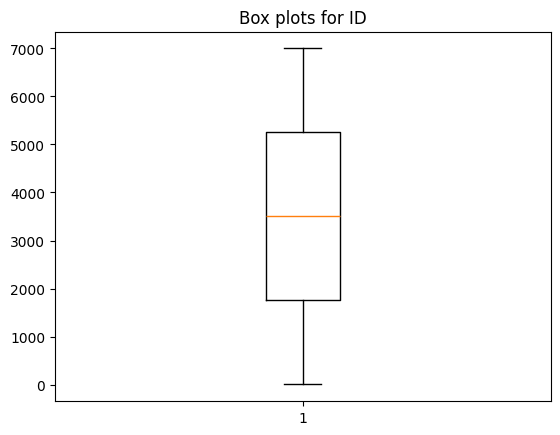

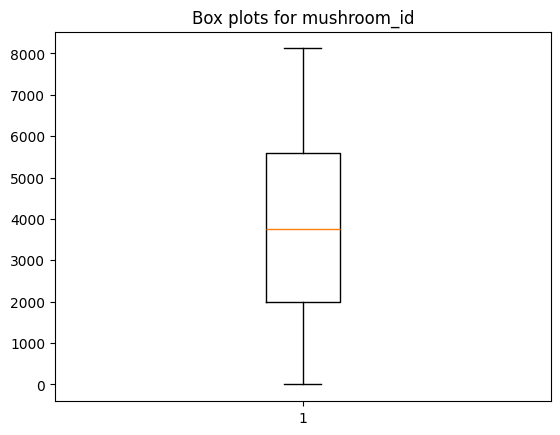

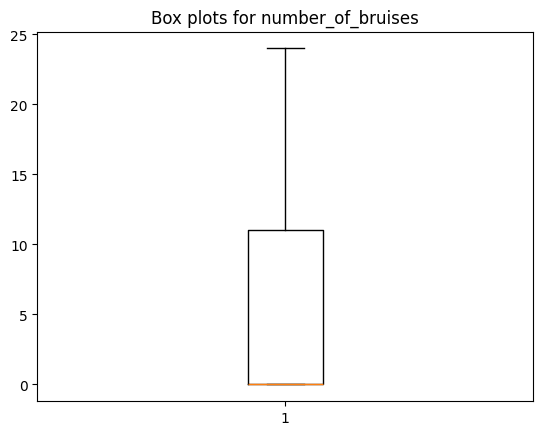

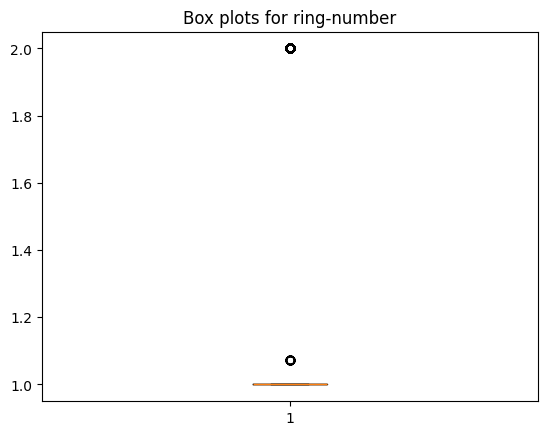

In [224]:
for i in numericals_cols[:-1]:
    plt.title(f"Box plots for {i}")
    plt.xlabel = i
    plt.boxplot(train_viz[i])
    # plt.violinplot(train[i])
    plt.show()

## Separting test and train data

In [ ]:
train_df = df[df["is_train"]==1]
test_df = df[df["is_train"]==0]

train_df = train_df.drop(["is_train"], axis = 1)
test_df = test_df.drop(["is_train"], axis = 1)

In [ ]:
train_df.shape, train.shape, test_df.shape, test.shape #to verify there's no leakage

((7000, 23), (7000, 27), (1124, 23), (1124, 26))

In [ ]:
#splitting dataset 
from sklearn.model_selection import train_test_split
X = train_df.drop(["class"], axis = 1)
y = train_df["class"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size= 0.2, random_state=42, stratify=y
)

# Model Training 

In [ ]:
## Models

### CatBoost Classifier

In [ ]:
from catboost import CatBoostClassifier, Pool, metrics, cv
from sklearn.metrics import accuracy_score

model = CatBoostClassifier(
    custom_loss=[metrics.Accuracy()],
    random_seed = 42,
    logging_level = 'Silent'
)

cat_features = list(range(X_train.shape[1]))

In [ ]:
model.fit(
    X_train, y_train,
    cat_features=cat_features, 
    eval_set=(X_val, y_val),
    logging_level='Verbose',  # you can uncomment this for text output
    use_best_model=True,
    plot=True
)

In [ ]:
model.fit(
    X, y,
    cat_features=cat_features,
    verbose=100
)

In [ ]:
from sklearn.metrics import accuracy_score

val_preds = model.predict(X_val)
acc = accuracy_score(y_val, val_preds)

print("Validation Accuracy:", acc)

# Submission

In [ ]:
print(X_train.shape, X_val.shape)
test_preds = model.predict(test_df)
sample['class'] = test_preds
sample["class"].map({0.0: 'e', 1.0: 'p'})
df[df["class"].isna()]